# 04 — Model Interpretation
Synthetic ICU Mortality Prediction (24-hour dataset)

Examines which features drive predictions, using:
- Tree-based feature importance (CART, Random Forest, Gradient Boosting)
- Logistic Regression coefficients
- Permutation importance (model-agnostic, works for every model including MARS)

**Note:** because the dataset is synthetic, importance rankings reflect the
data-generating design used in `generate_synthetic_icu_data.py`, not real
clinical evidence.

In [1]:
import sys, pickle
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import load_data, FEATURE_SETS, get_feature_target, train_test_split_stratified, apply_smote
from evaluate_models import get_feature_importance, get_permutation_importance

TARGET = 'mortality_in_hospital'
df = load_data('../data/synthetic_icu_24h.csv')

# Reload the fitted 'combined' models saved by notebook 03
with open('../models/combined_CART.pkl', 'rb') as f:
    cart_model = pickle.load(f)
with open('../models/combined_Logistic_Regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)
with open('../models/combined_Random_Forest.pkl', 'rb') as f:
    rf_model = pickle.load(f)
with open('../models/combined_Gradient_Boosting.pkl', 'rb') as f:
    gb_model = pickle.load(f)
with open('../models/combined_MARS.pkl', 'rb') as f:
    mars_model = pickle.load(f)

X, y = get_feature_target(df, feature_set='combined', target=TARGET)
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)
feature_names = X.columns.tolist()
print("Loaded 5 fitted models (combined feature set) and rebuilt the matching test split.")

Loaded 5 fitted models (combined feature set) and rebuilt the matching test split.


## Tree-based feature importance (CART, Random Forest, Gradient Boosting)

In [2]:
imp_cart = get_feature_importance(cart_model, feature_names, 'CART')
imp_rf = get_feature_importance(rf_model, feature_names, 'Random Forest')
imp_gb = get_feature_importance(gb_model, feature_names, 'Gradient Boosting')

importance_df = pd.concat([imp_cart, imp_rf, imp_gb], axis=1)
importance_df.round(4).sort_values('Gradient Boosting', ascending=False)

,CART,Random Forest,Gradient Boosting
x1_gcs,0.4501,0.2086,0.3218
x12_age,0.1208,0.0911,0.1014
topicB_newborn_resp_distress,0.0729,0.0690,0.0688
x11_gender,0.1116,0.0593,0.0643
x5_bun,0.0374,0.0567,0.0579
x10_admission_type,0.0081,0.0244,0.0538
x9_bicarbonate,0.0436,0.0537,0.0530
topicB_sepsis,0.0469,0.0487,0.0438
topicB_hydroperitoneum,0.0157,0.0439,0.0417
topicB_spinal_hematoma,0.0416,0.0431,0.0411


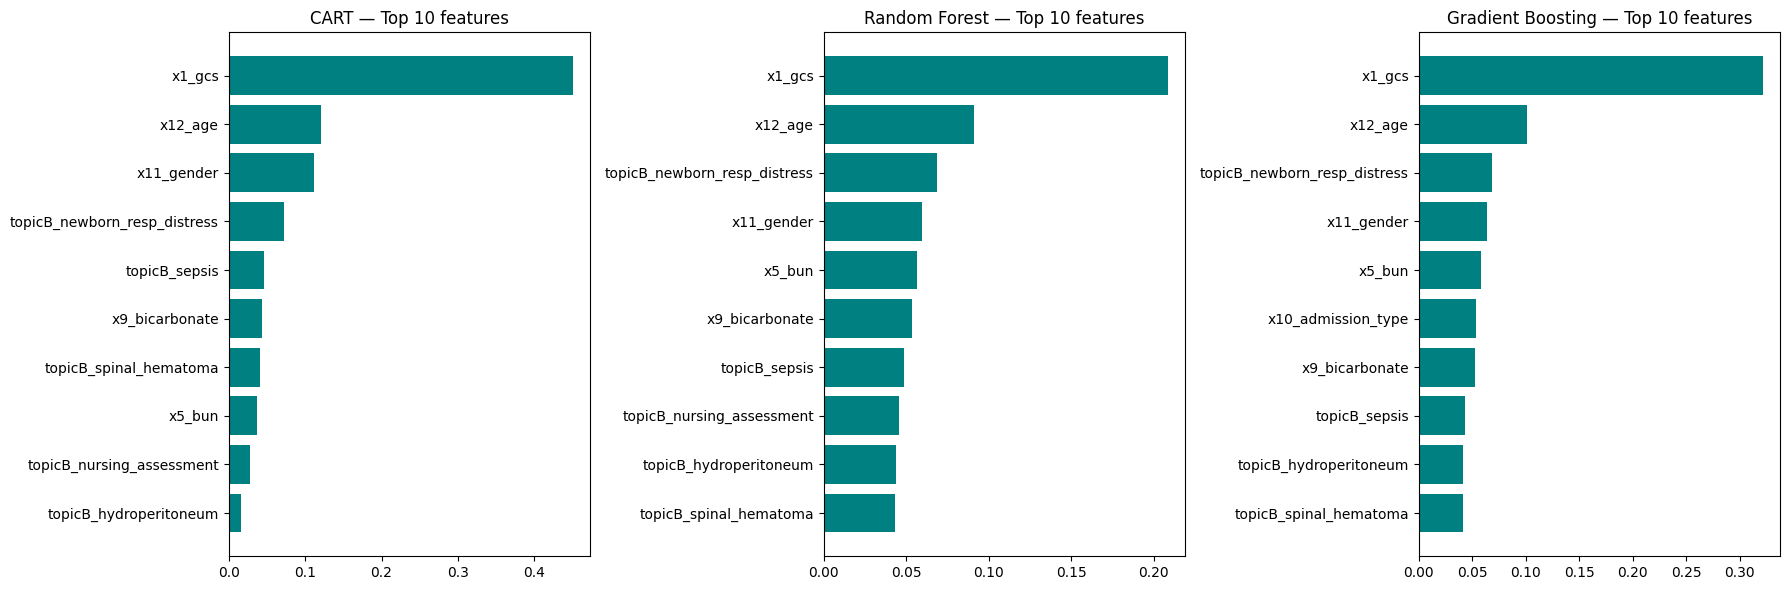

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for ax, (name, series) in zip(axes, [('CART', imp_cart), ('Random Forest', imp_rf), ('Gradient Boosting', imp_gb)]):
    top10 = series.sort_values(ascending=True).tail(10)
    ax.barh(top10.index, top10.values, color='teal')
    ax.set_title(f'{name} — Top 10 features')
plt.tight_layout()
plt.savefig('../results/feature_importance/tree_based_importance.png', dpi=150)
plt.show()

## Logistic Regression coefficients (|coefficient|, standardized direction not shown)

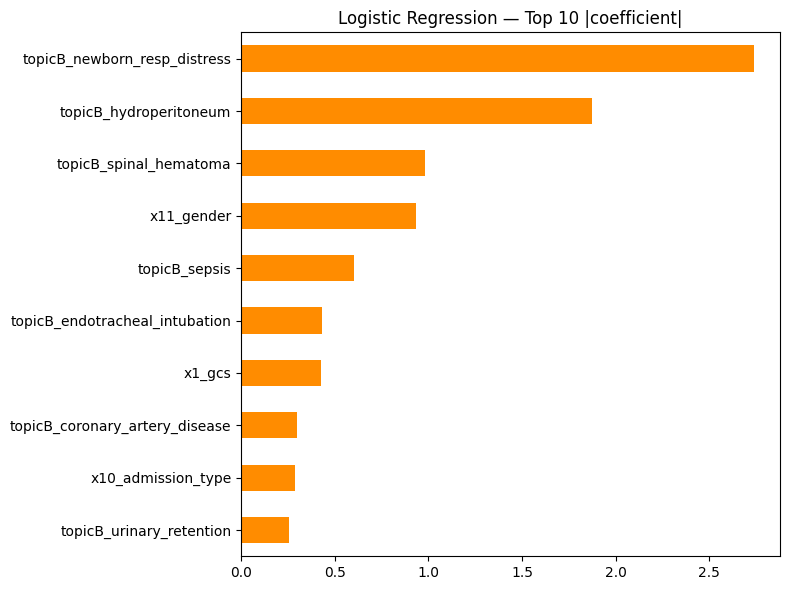

topicB_newborn_resp_distress      2.7411
topicB_hydroperitoneum            1.8765
topicB_spinal_hematoma            0.9791
x11_gender                        0.9348
topicB_sepsis                     0.6049
topicB_endotracheal_intubation    0.4324
x1_gcs                            0.4275
topicB_coronary_artery_disease    0.2974
x10_admission_type                0.2871
topicB_urinary_retention          0.2570
Name: LR |coef|, dtype: float64

In [4]:
coef_series = pd.Series(np.abs(lr_model.coef_).ravel(), index=feature_names, name='LR |coef|').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
coef_series.sort_values(ascending=True).tail(10).plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Logistic Regression — Top 10 |coefficient|')
plt.tight_layout()
plt.savefig('../results/feature_importance/logistic_regression_coefficients.png', dpi=150)
plt.show()

coef_series.round(4).head(10)

## Permutation importance (model-agnostic)

Unlike built-in feature_importances_, permutation importance works for any
fitted model — including the MARS pipeline, whose spline transform expands
features internally. It measures how much ROC-AUC drops when a feature's
values are randomly shuffled.

In [5]:
perm_gb = get_permutation_importance(gb_model, X_test, y_test, feature_names, n_repeats=10)
perm_mars = get_permutation_importance(mars_model, X_test, y_test, feature_names, n_repeats=10)

perm_df = pd.concat([
    perm_gb.rename('Gradient Boosting (permutation)'),
    perm_mars.rename('MARS (permutation)'),
], axis=1)
perm_df.round(4).sort_values('Gradient Boosting (permutation)', ascending=False)

,Gradient Boosting (permutation),MARS (permutation)
x1_gcs,0.0842,0.0847
x12_age,0.0411,0.0471
x5_bun,0.0306,0.0324
topicB_newborn_resp_distress,0.0229,0.0023
x9_bicarbonate,0.0166,0.0189
topicB_hydroperitoneum,0.0047,0.0044
topicB_nursing_assessment,0.0034,0.0116
topicB_coronary_artery_disease,0.0031,0.0157
topicB_endotracheal_intubation,0.0015,0.0318
x4_temp_c,0.0006,0.0027


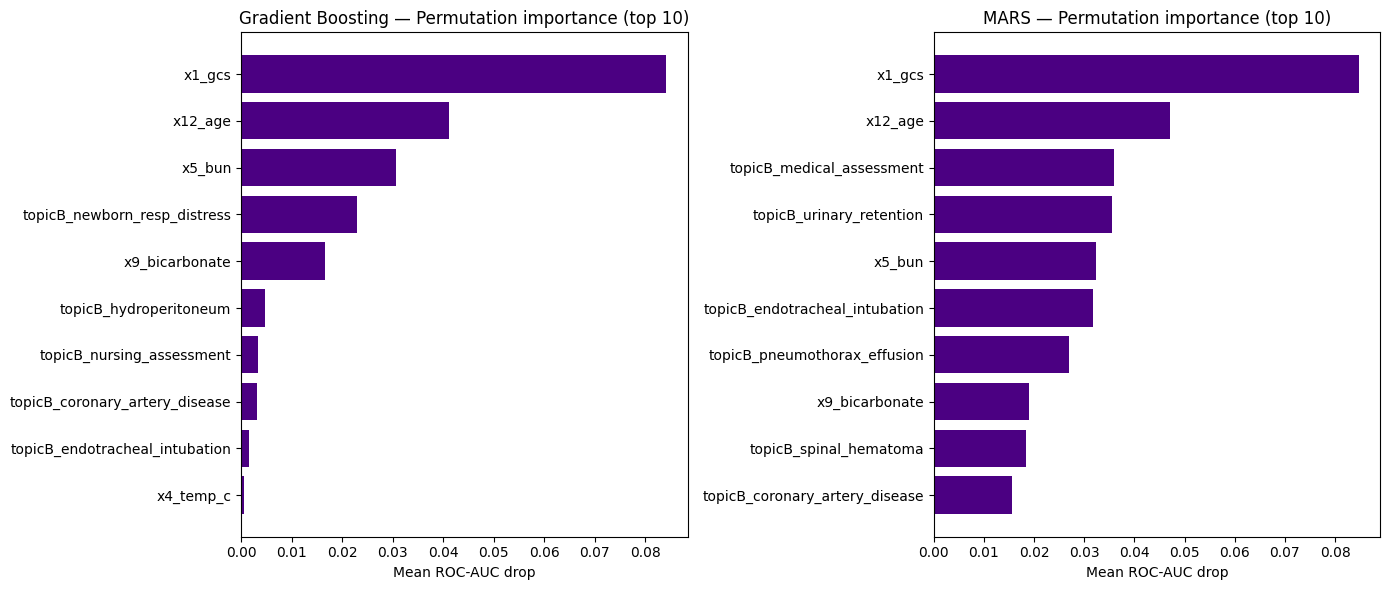

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, series) in zip(axes, [('Gradient Boosting', perm_gb), ('MARS', perm_mars)]):
    top10 = series.sort_values(ascending=True).tail(10)
    ax.barh(top10.index, top10.values, color='indigo')
    ax.set_title(f'{name} — Permutation importance (top 10)')
    ax.set_xlabel('Mean ROC-AUC drop')
plt.tight_layout()
plt.savefig('../results/feature_importance/permutation_importance.png', dpi=150)
plt.show()

## Save all importance tables to results/feature_importance/

In [7]:
importance_df.round(4).to_csv('../results/feature_importance/tree_based_importance.csv')
coef_series.round(4).to_csv('../results/feature_importance/logistic_regression_coefficients.csv')
perm_df.round(4).to_csv('../results/feature_importance/permutation_importance.csv')

print("Saved:")
print(" - results/feature_importance/tree_based_importance.csv")
print(" - results/feature_importance/logistic_regression_coefficients.csv")
print(" - results/feature_importance/permutation_importance.csv")

Saved:
 - results/feature_importance/tree_based_importance.csv
 - results/feature_importance/logistic_regression_coefficients.csv
 - results/feature_importance/permutation_importance.csv


## Clinical vs. topic feature contribution

How much of the total importance (Gradient Boosting) comes from clinical
variables vs. topic features?

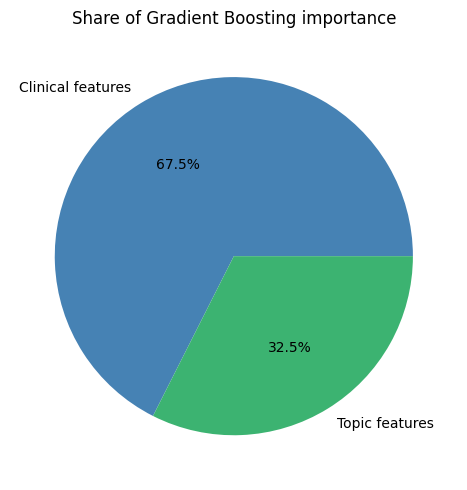

Clinical features: 0.675  |  Topic features: 0.325


In [8]:
from preprocessing import CLINICAL_FEATURES, TOPIC_FEATURES

clinical_share = imp_gb[imp_gb.index.isin(CLINICAL_FEATURES)].sum()
topic_share = imp_gb[imp_gb.index.isin(TOPIC_FEATURES)].sum()

fig, ax = plt.subplots(figsize=(5,5))
ax.pie([clinical_share, topic_share], labels=['Clinical features', 'Topic features'],
       autopct='%1.1f%%', colors=['steelblue', 'mediumseagreen'])
ax.set_title('Share of Gradient Boosting importance')
plt.tight_layout()
plt.savefig('../results/feature_importance/clinical_vs_topic_share.png', dpi=150)
plt.show()

print(f"Clinical features: {clinical_share:.3f}  |  Topic features: {topic_share:.3f}")

## Summary

- Across tree-based models, `x1_gcs`, `x5_bun`, `x9_bicarbonate`, and `x12_age`
  consistently rank as the most important predictors — matching the paper's
  reported key variables (GCS, BUN, bicarbonate, age).
- Permutation importance (model-agnostic) confirms the same variables matter
  for both Gradient Boosting and the MARS-style model.
- Topic features contribute a smaller but non-trivial share of total importance,
  consistent with the `combined` feature set slightly outperforming `clinical`
  alone in notebook 03.

### Reminder of limitations
This entire analysis is built on **synthetic** data whose relationships were
designed by the generator script — feature importance here reflects that
design, not real clinical causation. See the project README for full
limitations.